# Segmentación de Sellers — PCA + K-Means

En vez de tratar a los +3.000 sellers de Olist como un bloque, buscamos los grupos naturales en los que se dividen según su comportamiento (volumen, revenue, ticket promedio, flete, reviews, distancia a sus compradores, variedad de catálogo). Es el segundo eje analítico del proyecto (ver README).

Partimos de `seller_features` (armada por `build_seller_features()` en `src/data.py`), que ya tiene una fila por seller con esas métricas agregadas.

## 1. Carga de datos

In [1]:
import os
import sys

project_root = '.' if os.path.isdir('src') else '..'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

from src.data import build_datasets

order_items_full, seller_features = build_datasets(save=False)
seller_features.shape

(3095, 10)

## 2. Exploración rápida antes de modelar

Dos cosas que hay que resolver antes de meter esto en K-Means:

1. **`n_orders` y `n_items` están correlacionados 0.99** (son casi la misma señal: cantidad de compras vs. cantidad de items). Usamos solo `n_orders` para no pesarla doble.
2. **La distribución está muy sesgada**: la mediana es 6 órdenes por seller, pero el máximo es 1.854, y el 18.5% de los sellers tiene una sola orden. K-Means mide distancias euclidianas — sin corregir esto, los pocos sellers gigantes dominan la métrica y el resto queda todo amontonado en un solo cluster.

In [2]:
print(seller_features[['n_orders', 'n_items', 'revenue', 'avg_ticket', 'avg_freight', 'avg_review_score', 'avg_distance_km']].corr().round(2))
print()
print(f"Sellers con 1 sola orden: {(seller_features['n_orders'] == 1).sum()} / {len(seller_features)}")
print()
print(seller_features['n_orders'].describe())

                  n_orders  n_items  revenue  avg_ticket  avg_freight  \
n_orders              1.00     0.99     0.80       -0.05        -0.05   
n_items               0.99     1.00     0.80       -0.05        -0.05   
revenue               0.80     0.80     1.00        0.10         0.04   
avg_ticket           -0.05    -0.05     0.10        1.00         0.56   
avg_freight          -0.05    -0.05     0.04        0.56         1.00   
avg_review_score      0.02     0.02     0.02       -0.02        -0.03   
avg_distance_km      -0.01    -0.01     0.03        0.15         0.31   

                  avg_review_score  avg_distance_km  
n_orders                      0.02            -0.01  
n_items                       0.02            -0.01  
revenue                       0.02             0.03  
avg_ticket                   -0.02             0.15  
avg_freight                  -0.03             0.31  
avg_review_score              1.00            -0.02  
avg_distance_km              -0.02   

## 3. Preprocesamiento: features, log-transform y escalado

In [3]:
df = seller_features.dropna(subset=['avg_review_score', 'avg_distance_km']).copy()
print(f"Sellers usados: {len(df)} de {len(seller_features)} (se descartan {len(seller_features) - len(df)} sin review o sin distancia)")

# n_orders, revenue, avg_ticket, avg_freight y n_categories tienen cola larga -> log1p
# avg_review_score y avg_distance_km ya son razonablemente simetricas, quedan tal cual.
log_cols = ['n_orders', 'revenue', 'avg_ticket', 'avg_freight', 'n_categories']
feature_cols = log_cols + ['avg_review_score', 'avg_distance_km']

X = df[feature_cols].copy()
for col in log_cols:
    X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)
X_scaled.describe().round(2)

Sellers usados: 3083 de 3095 (se descartan 12 sin review o sin distancia)


,n_orders,revenue,avg_ticket,avg_freight,n_categories,avg_review_score,avg_distance_km
count,3083.00,3083.00,3083.00,3083.00,3083.00,3083.00,3083.00
mean,0.00,-0.00,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.15,-2.85,-3.26,-4.76,-2.13,-3.06,-1.55
25%,-0.85,-0.76,-0.68,-0.62,-0.63,-0.27,-0.60
50%,-0.14,-0.02,-0.06,-0.19,-0.63,0.20,-0.16
75%,0.62,0.73,0.57,0.39,0.25,0.65,0.37
max,3.83,3.04,4.35,5.65,5.08,1.06,5.55


## 4. PCA — solo para visualizar, no para clusterizar

Con 7 features no necesitamos PCA para "reducir dimensionalidad" en el sentido clásico; lo usamos para poder graficar los clusters en 2D y para chequear cuánta información se pierde al proyectar. El clustering en sí lo hacemos sobre las 7 features escaladas, no sobre los componentes — así los centroides se pueden leer directamente en unidades reales (log de revenue, de n_orders, etc.) en vez de combinaciones abstractas de componentes.

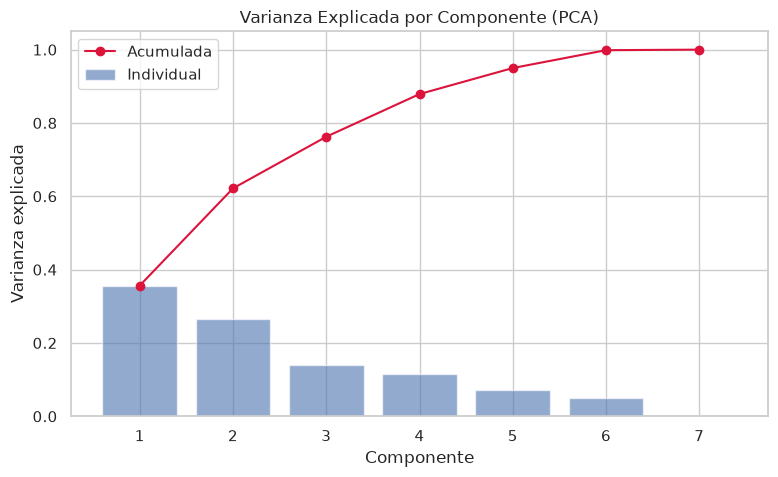

PC1 + PC2 explican 62.2% de la varianza total


In [4]:
pca = PCA(random_state=42)
pca.fit(X_scaled)

plt.figure(figsize=(9, 5))
plt.bar(range(1, len(feature_cols) + 1), pca.explained_variance_ratio_, alpha=0.6, label='Individual')
plt.plot(range(1, len(feature_cols) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='crimson', label='Acumulada')
plt.xlabel('Componente')
plt.ylabel('Varianza explicada')
plt.title('Varianza Explicada por Componente (PCA)')
plt.legend()
plt.show()

print(f"PC1 + PC2 explican {np.cumsum(pca.explained_variance_ratio_)[1]:.1%} de la varianza total")

## 5. Eligiendo K: método del codo + silhouette score

El codo (inertia) nunca es muy marcado con datos de comportamiento real, así que lo combinamos con el silhouette score (qué tan bien separados quedan los clusters, de -1 a 1).

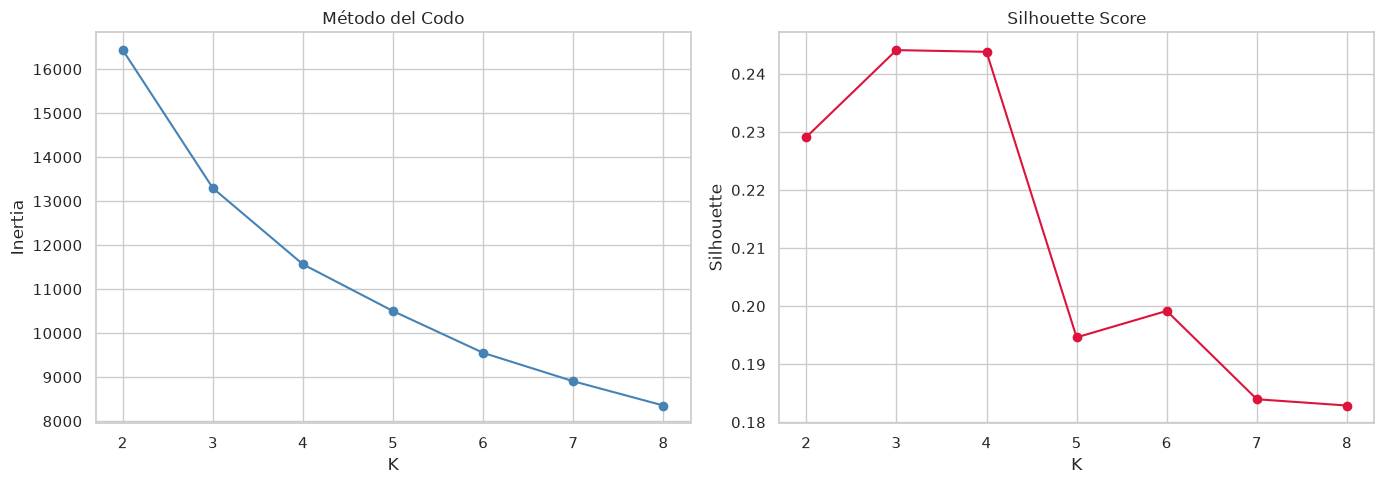

k=2: inertia=16434  silhouette=0.229
k=3: inertia=13296  silhouette=0.244
k=4: inertia=11564  silhouette=0.244
k=5: inertia=10501  silhouette=0.195
k=6: inertia=9552  silhouette=0.199
k=7: inertia=8907  silhouette=0.184
k=8: inertia=8355  silhouette=0.183


In [5]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(k_range), inertias, marker='o', color='steelblue')
ax1.set_title('Método del Codo')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')

ax2.plot(list(k_range), silhouettes, marker='o', color='crimson')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"k={k}: inertia={inertia:.0f}  silhouette={sil:.3f}")

**Elegimos K=4.** El silhouette es prácticamente el mismo que en K=3 (0.244 en ambos), pero K=4 separa un grupo con `avg_review_score` muy por debajo del resto que en K=3 queda escondido dentro de otro cluster — y ese grupo es justo el más accionable para el negocio (ver interpretación más abajo). Ante un empate en la métrica, preferimos la segmentación que aporta más señal de negocio.

## 6. Entrenamos K-Means (K=4) y perfilamos los clusters

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_sizes = df['cluster'].value_counts().sort_index()
cluster_profile = df.groupby('cluster')[feature_cols].mean().round(2)
cluster_profile['n_sellers'] = cluster_sizes
cluster_profile

,n_orders,revenue,avg_ticket,avg_freight,n_categories,avg_review_score,avg_distance_km,n_sellers
cluster,,,,,,,,
0,2.40,290.80,110.39,18.45,1.09,1.93,544.95,350
1,5.53,446.08,83.54,16.39,1.30,4.46,476.72,1198
2,93.54,11606.67,130.42,19.82,3.81,4.06,583.80,936
3,7.96,3435.68,461.81,45.62,1.39,4.06,970.29,599


## 7. Visualización de los clusters en el plano PCA

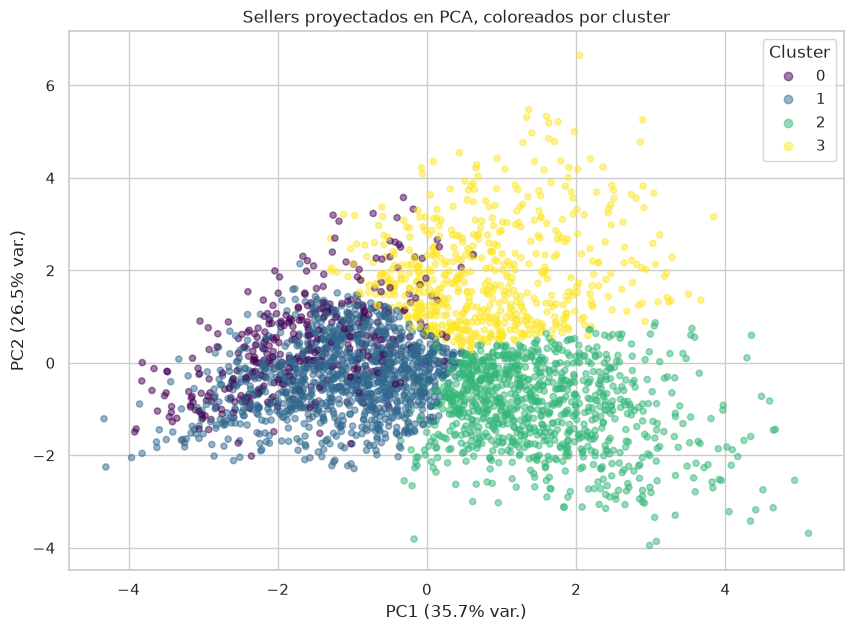

In [7]:
X_pca = pca.transform(X_scaled)[:, :2]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', alpha=0.5, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)')
plt.title('Sellers proyectados en PCA, coloreados por cluster')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

## 8. Interpretación y recomendación por cluster

| Cluster | # Sellers | Perfil | Recomendación |
|---|---|---|---|
| **0 — En riesgo** | 350 (11%) | Bajo volumen (2.4 órdenes), bajo revenue (R$291), catálogo angosto (1.1 categorías) y **review promedio 1.93** — muy por debajo de cualquier otro grupo. | Es el único cluster con problema de calidad, no de tamaño. Justifica intervención directa: revisar por qué la satisfacción es tan baja (¿logística, producto, atención?) antes de invertir en hacerlos crecer — meterles más volumen a un seller con reviews de 1.93 solo escala el daño reputacional al marketplace. |
| **1 — Pequeños y confiables** | 1.198 (39%) | El grupo más grande. Bajo volumen (5.5 órdenes) y revenue (R$446), pero la **mejor review del dataset (4.46)** y la distancia más corta a sus compradores (477 km). | Base sana del marketplace: venden poco pero lo hacen bien y cerca. Candidatos naturales para programas de crecimiento (ampliar catálogo, incentivos) — el riesgo de escalarlos es bajo porque ya demuestran buen servicio. |
| **2 — Power sellers** | 936 (30%) | Volumen muy alto (93.5 órdenes, ~17x el promedio de los otros clusters), el revenue más alto por lejos (R$11.607) y el catálogo más amplio (3.8 categorías), con buena review (4.06). | Las cuentas clave del marketplace. Prioridad de retención: gestor de cuenta dedicado, condiciones preferenciales — perder uno de estos sellers pesa mucho más que perder uno del cluster 1. |
| **3 — Nicho premium** | 599 (19%) | Volumen moderado (8 órdenes) pero el **ticket promedio más alto por lejos (R$462, ~4-5x el resto)**, catálogo angosto (1.4 categorías), buena review (4.06) y la distancia más larga a sus compradores (970 km) — coherente con el flete más caro del dataset (R$45.6). | Venden pocas unidades pero caras, y a nivel nacional. El flete alto es la fricción más visible: vale la pena explorar tarifas negociadas de transporte para este grupo antes que estrategias de volumen, que no calzan con su perfil. |

**Limitaciones:** el silhouette score (0.24) es modesto — los clusters existen pero se superponen bastante, típico de comportamiento real (no hay fronteras naturales tan nítidas como en datos sintéticos). PC1+PC2 solo capturan 62% de la varianza, así que el scatter 2D es una simplificación: dos sellers que se ven cerca ahí pueden diferir en las dimensiones que no se ven (PC3 en adelante).